# Algoritmos de optimización - Seminario<br>
**Nombre y Apellidos:**

Nur Derly Carpeta Sánchez

William René Moreno Romero<br>

Github: https://github.com/renemorenow/VIU-AlgoritmosOptimizacion/blob/main/PROBLEMA/Seminario_Algoritmos_problema3.ipynb<br>

Colab: https://colab.research.google.com/drive/1LplnLSj7ODcLlCmOqo0VTLTnxrmfExsi?usp=sharing<br>

**Problema:**
> 1. ~~Sesiones de doblaje~~ <br>
>2. ~~Organizar los horarios de partidos de La Liga~~<br>
>3. **Combinar cifras y operaciones**

**Descripción del problema:**

El problema consiste en analizar el siguiente problema y diseñar un algoritmo que lo resuelva.

- Disponemos de las 9 cifras del 1 al 9 (excluimos el cero) y de los 4 signos básicos de las operaciones fundamentales: suma(+), resta(-), multiplicación(*) y división(/)

- Debemos combinarlos alternativamente sin repetir ninguno de ellos para obtener una cantidad dada. Un ejemplo sería para obtener el 4:

>  4+2-6/3*1 = 4

Debe analizarse el problema para encontrar todos los valores enteros posibles planteando las siguientes preguntas:

- ¿Qué valor máximo y mínimo se pueden obtener según las condiciones del problema?
- ¿Es posible encontrar todos los valores enteros posibles entre dicho mínimo y máximo?

Nota: Es posible usar la función de python "eval" para evaluar una expresión:

```python
expresion = "4-2+6/3*1"
print(eval(expresion))       # 4.0
```

(*) La respuesta es obligatoria

---

### Índice

| # | Pregunta |
|---|---|
| 1 | Número de posibilidades sin y con restricciones |
| 2 | Estructura de datos que mejor se adapta al problema |
| 3 | Función objetivo. ¿Maximización o minimización? |
| 4 | Algoritmo por fuerza bruta |
| 5 | Complejidad del algoritmo por fuerza bruta |
| 6 | Algoritmo que mejora la complejidad de la fuerza bruta |
| 7 | Complejidad del algoritmo propuesto |
| 8 | Juego de datos de entrada aleatorios |
| 9 | Aplicación del algoritmo al juego de datos |
| 10 | Referencias |
| 11 | Líneas de avance |

### Resumen de resultados

| Magnitud | Valor |
|---|---|
| Expresiones válidas distintas | 362 880 |
| Expresiones con resultado entero | 90 000 (24,8 %) |
| Valor entero mínimo | **−69** |
| Valor entero máximo | **77** |
| Valores enteros distintos alcanzables | **147** |
| Enteros del intervalo [−69, 77] no alcanzables | **ninguno** |

In [ ]:
# Import de Librerías
import time
import random
from math import factorial
from fractions import Fraction
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 2026
random.seed(SEMILLA)            # reproducibilidad de los datos aleatorios

# Estilo común de las figuras
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
AZUL, NARANJA, VERDE, GRIS = 'steelblue', 'darkorange', 'mediumseagreen', '0.75'

# Datos del problema
CIFRAS     = list(range(1, 10))     # 9 cifras, del 1 al 9 (se excluye el cero)
OPERADORES = ['+', '-', '*', '/']   # 4 operadores, sin repetición
K_CIFRAS   = 5                      # cifras que intervienen en cada expresión
K_OPS      = 4                      # operadores que intervienen en cada expresión

print('Cifras disponibles :', CIFRAS)
print('Operadores         :', OPERADORES)
print('Estructura de una expresión: d1 op1 d2 op2 d3 op3 d4 op4 d5')
print('  ->', K_CIFRAS, 'cifras distintas y', K_OPS, 'operadores distintos')

Cifras disponibles : [1, 2, 3, 4, 5, 6, 7, 8, 9]
Operadores         : ['+', '-', '*', '/']
Estructura de una expresión: d1 op1 d2 op2 d3 op3 d4 op4 d5
  -> 5 cifras distintas y 4 operadores distintos


---
## 1. (\*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>

¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.

**Respuesta:**

Una expresión del problema tiene la forma `d1 op1 d2 op2 d3 op3 d4 op4 d5`: **cinco huecos de cifra
y cuatro huecos de operador**, siempre alternados. Contar posibilidades es contar de cuántas maneras
se pueden rellenar esos nueve huecos.

**Sin tener en cuenta las restricciones.** Si se permite repetir cifras y operadores, cada hueco de
cifra admite cualquiera de las 9 cifras y cada hueco de operador cualquiera de los 4 signos:

$$9^{5} \times 4^{4} = 59\,049 \times 256 = 15\,116\,544$$

**Teniendo en cuenta todas las restricciones.** El enunciado impone combinar las cifras y los signos
*"sin repetir ninguno de ellos"*. Esto introduce dos restricciones independientes:

- **(R1)** las 5 cifras deben ser distintas entre sí, luego se trata de una **variación sin
  repetición** de 5 elementos tomados de 9;
- **(R2)** los 4 operadores deben ser distintos, y como hay exactamente 4 operadores disponibles,
  esto obliga a usar **los cuatro, cada uno una sola vez**: son las permutaciones de 4 elementos.

$$P(9,5) \times 4! = \frac{9!}{4!} \times 4! = 15\,120 \times 24 = 362\,880$$

Las restricciones reducen el espacio a un **2,4 % del original**, unas 42 veces menos.

**Una consecuencia estructural de (R2) que se aprovechará más adelante.** Como los cuatro operadores
aparecen obligatoriamente una vez cada uno, toda expresión contiene **exactamente un `+` y
exactamente un `−`**. Puesto que la suma y la resta tienen menor precedencia que el producto y la
división, esto significa que toda expresión se descompone siempre en **exactamente tres bloques
multiplicativos**. Esta observación será la clave del análisis del máximo y del mínimo (pregunta 3).

In [ ]:
# Pregunta 1 · Cardinalidad del espacio de soluciones

def variaciones(n, k):
    """Variaciones sin repetición: P(n,k) = n! / (n-k)!"""
    return factorial(n) // factorial(n - k)

sin_restricciones = len(CIFRAS) ** K_CIFRAS * len(OPERADORES) ** K_OPS
p_cifras = variaciones(len(CIFRAS), K_CIFRAS)      # P(9,5) = 15.120
p_ops    = factorial(len(OPERADORES))              # 4!     = 24
con_restricciones = p_cifras * p_ops

print(f"SIN restricciones   9^5 x 4^4      = {sin_restricciones:>12,}")
print(f"  cifras con repetición   9^5      = {len(CIFRAS)**K_CIFRAS:>12,}")
print(f"  operadores con repetición 4^4    = {len(OPERADORES)**K_OPS:>12,}")
print()
print(f"CON restricciones   P(9,5) x 4!    = {con_restricciones:>12,}")
print(f"  variaciones de cifras P(9,5)     = {p_cifras:>12,}")
print(f"  permutaciones de operadores 4!   = {p_ops:>12,}")
print()
print(f"El espacio queda en el {100*con_restricciones/sin_restricciones:.1f} % del original "
      f"({sin_restricciones/con_restricciones:.0f} veces menor)")

SIN restricciones   9^5 x 4^4      =   15,116,544
  cifras con repetición   9^5      =       59,049
  operadores con repetición 4^4    =          256

CON restricciones   P(9,5) x 4!    =      362,880
  variaciones de cifras P(9,5)     =       15,120
  permutaciones de operadores 4!   =           24

El espacio queda en el 2.4 % del original (42 veces menor)


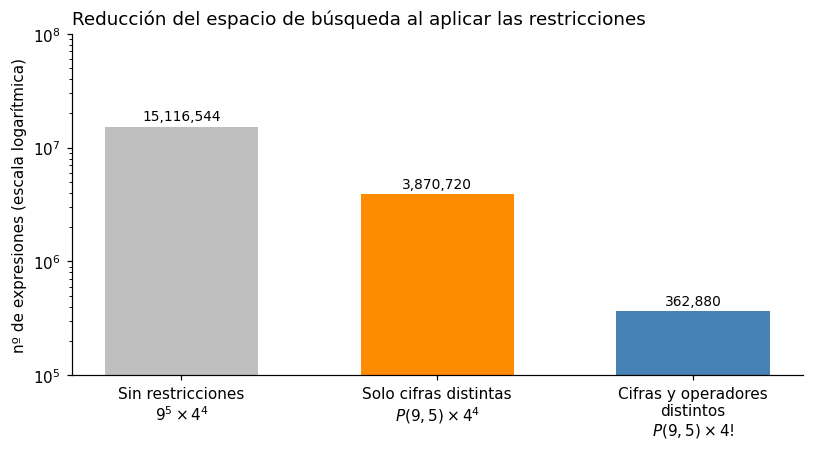

Cada restricción divide el espacio: primero por 3.9 (cifras distintas) y después por 10.7 (operadores distintos).


In [ ]:
# Figura 1 · Efecto de cada restricción sobre el tamaño del espacio
etapas = ['Sin restricciones\n$9^5 \\times 4^4$',
          'Solo cifras distintas\n$P(9,5) \\times 4^4$',
          'Cifras y operadores\ndistintos\n$P(9,5) \\times 4!$']
valores = [sin_restricciones, p_cifras * len(OPERADORES) ** K_OPS, con_restricciones]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
barras = ax.bar(etapas, valores, color=[GRIS, NARANJA, AZUL], width=0.6)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v * 1.15, f"{v:,}", ha='center', fontsize=9)
ax.set_yscale('log')
ax.set_ylim(1e5, 1e8)
ax.set_ylabel('nº de expresiones (escala logarítmica)')
ax.set_title('Reducción del espacio de búsqueda al aplicar las restricciones', loc='left')
plt.tight_layout(); plt.show()

print(f"Cada restricción divide el espacio: primero por "
      f"{sin_restricciones/(p_cifras*len(OPERADORES)**K_OPS):.1f} (cifras distintas) "
      f"y después por {len(OPERADORES)**K_OPS/p_ops:.1f} (operadores distintos).")

---
## 2. Modelo para el espacio de soluciones<br>
(\*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)

**Respuesta:**

### Primera elección: cadenas de texto y `eval()`

La primera representación empleada fue la más directa y la que sugiere el propio enunciado: construir
cada expresión como una **cadena de caracteres** (`"4+2-6/3*1"`) y evaluarla con `eval()`. Su ventaja
es evidente: `eval()` resuelve por sí solo la precedencia de operadores, de modo que no hay que
programar ningún analizador.

### Por qué fue necesario cambiarla

Al medir el coste de recorrer las 362 880 expresiones se comprobó que la mayor parte del tiempo no se
consume en la aritmética, sino en `eval()`: cada llamada **compila la cadena** antes de evaluarla, y
esa compilación se repite 362 880 veces. La medición aparece más abajo: el recorrido completo pasa de
unos 2,5 s a unos 0,25 s con solo cambiar la representación.

### Representación adoptada: tuplas de enteros y dos acumuladores

La expresión se representa como **dos tuplas de enteros**: una con las 5 cifras y otra con los
índices de los 4 operadores. La evaluación se realiza en una sola pasada mediante dos acumuladores:

- `suma`: los términos aditivos que ya están cerrados;
- `termino`: el bloque de multiplicaciones y divisiones que está en curso.

Al encontrar `*` o `/` se sigue acumulando dentro de `termino`; al encontrar `+` o `−` se cierra el
término en curso, se suma a `suma` y se abre uno nuevo. De esta forma **se respeta la precedencia de
operadores sin necesidad de `eval()` ni de análisis sintáctico**, y el coste por expresión se reduce
a cuatro operaciones aritméticas.

Este cambio no es solo una optimización: es lo que hace posible el algoritmo de vuelta atrás de la
pregunta 6, porque permite **arrastrar el estado parcial** (`suma`, `termino`) al descender por el
árbol de búsqueda, en lugar de reevaluar la expresión completa en cada nodo.

### Estructuras auxiliares

| Estructura | Uso | Motivo de la elección |
|---|---|---|
| `tuple` de enteros | cifras y operadores de una expresión | inmutable y ligera; sirve de clave y evita copias accidentales |
| `set` | valores enteros alcanzados | elimina duplicados automáticamente y la pertenencia es O(1); con `list` la comprobación de huecos de la pregunta 4 sería O(n) por consulta |
| `set` | cifras y operadores ya usados en la rama | comprobar "¿está usado?" en O(1) dentro del backtracking |

Se descartó guardar la expresión completa de cada resultado: para responder a las preguntas del
enunciado basta con el **conjunto de valores**, y almacenar las 90 000 expresiones que dan entero
multiplicaría el consumo de memoria sin aportar nada.

In [ ]:
# Pregunta 2 · Las dos representaciones, y la medición que motivó el cambio

# --- Representación 1 (inicial): cadena de texto + eval() ---
def construir_cadena(cifras, ops):
    """Devuelve la expresión como texto: d1 op1 d2 ... op4 d5"""
    partes = []
    for i in range(len(cifras)):
        partes.append(str(cifras[i]))
        if i < len(ops):
            partes.append(ops[i])
    return ''.join(partes)


def evaluar_con_eval(cifras, ops):
    return eval(construir_cadena(cifras, ops))


# --- Representación 2 (definitiva): tuplas de enteros + dos acumuladores ---
def evaluar(cifras, ops):
    """Evalúa d1 op1 d2 op2 d3 op3 d4 op4 d5 en una sola pasada.

    suma    -> términos aditivos ya cerrados
    termino -> bloque de multiplicaciones y divisiones en curso

    Respeta la precedencia sin usar eval(): '*' y '/' continúan el término
    en curso; '+' y '-' lo cierran y abren uno nuevo.
    """
    suma = 0.0
    termino = float(cifras[0])
    for i in range(len(ops)):        # funciona para cualquier nº de cifras (pregunta 9)
        op, d = ops[i], cifras[i + 1]
        if op == '*':
            termino *= d
        elif op == '/':
            termino /= d
        elif op == '+':
            suma += termino
            termino = float(d)
        else:                       # '-'
            suma += termino
            termino = -float(d)
    return suma + termino


# --- Validación: el evaluador propio debe coincidir con eval() ---
ejemplos = [((4, 2, 6, 3, 1), ('+', '-', '/', '*')),   # ejemplo del enunciado
            ((4, 2, 6, 3, 1), ('-', '+', '/', '*'))]   # ejemplo de la nota sobre eval
print('Validación del evaluador propio frente a eval():')
for cifras, ops in ejemplos:
    expr = construir_cadena(cifras, ops)
    print(f"  {expr:<12} evaluar() = {evaluar(cifras, ops):<6} "
          f"eval() = {eval(expr):<6} coinciden: {evaluar(cifras, ops) == eval(expr)}")

Validación del evaluador propio frente a eval():
  4+2-6/3*1    evaluar() = 4.0    eval() = 4.0    coinciden: True
  4-2+6/3*1    evaluar() = 4.0    eval() = 4.0    coinciden: True


In [ ]:
# Medición que justifica el cambio de representación
def recorrer(evaluador):
    """Recorre las 362.880 expresiones con el evaluador indicado."""
    alcanzados = set()
    for cifras in permutations(CIFRAS, K_CIFRAS):
        for ops in permutations(OPERADORES, K_OPS):
            v = evaluador(cifras, ops)
            if float(v).is_integer():
                alcanzados.add(int(v))
    return alcanzados

t0 = time.perf_counter(); conj_eval = recorrer(evaluar_con_eval); t_eval = time.perf_counter() - t0
t0 = time.perf_counter(); conj_dir  = recorrer(evaluar);          t_dir  = time.perf_counter() - t0

FACTOR_MEJORA = t_eval / t_dir     # se reutiliza en el texto para no fijar números a mano

print(f"Cadena de texto + eval()   : {t_eval:6.2f} s")
print(f"Tuplas + acumuladores      : {t_dir:6.2f} s")
print(f"Factor de mejora           : x{FACTOR_MEJORA:.1f}")
print(f"Ambas representaciones producen el mismo conjunto: {conj_eval == conj_dir}")
print(f"Valores enteros distintos  : {len(conj_dir)}")

Cadena de texto + eval()   :   5.63 s
Tuplas + acumuladores      :   0.34 s
Factor de mejora           : x16.6
Ambas representaciones producen el mismo conjunto: True
Valores enteros distintos  : 147


---
## 3. Según el modelo para el espacio de soluciones<br>
(\*)¿Cual es la función objetivo?

(\*)¿Es un problema de maximización o minimización?

**Respuesta:**

### Función objetivo

Sea una solución candidata el par $(d_1,\dots,d_5;\ op_1,\dots,op_4)$ con $d_i$ cifras distintas de
$\{1,\dots,9\}$ y $op_j$ los cuatro operadores sin repetición. La función objetivo es el **valor
aritmético de la expresión**, evaluada con la precedencia habitual:

$$f(d_1,\dots,d_5;\ op_1,\dots,op_4) \;=\; d_1\ op_1\ d_2\ op_2\ d_3\ op_3\ d_4\ op_4\ d_5$$

Su dominio es el conjunto de las 362 880 expresiones válidas y su recorrido es un subconjunto de
$\mathbb{Q}$. El enunciado restringe el interés a las expresiones con **valor entero**, de modo que
el conjunto relevante es

$$V = \{\, f(x) \;:\; x \text{ expresión válida},\ f(x)\in\mathbb{Z} \,\}$$

### ¿Maximización o minimización?

Conviene precisarlo, porque la respuesta no es inmediata: **en su formulación principal este no es un
problema de optimización, sino de enumeración y satisfacción de restricciones**. Lo que se pide es
*caracterizar todo el conjunto* $V$ —cuáles son sus elementos y si es un intervalo completo de
enteros—, no encontrar el mejor elemento según un criterio.

Ahora bien, las dos preguntas concretas del enunciado sí son de optimización, y **de los dos tipos a
la vez**:

| Pregunta del enunciado | Tipo | Formulación |
|---|---|---|
| ¿Qué valor **máximo** se puede obtener? | Maximización | $\max V$ |
| ¿Qué valor **mínimo** se puede obtener? | Minimización | $\min V$ |
| ¿Están todos los enteros intermedios? | Satisfacción | $V \stackrel{?}{=} [\min V, \max V] \cap \mathbb{Z}$ |

Y existe una tercera variante, la que plantea el propio enunciado al hablar de *"obtener una cantidad
dada"* (el ejemplo `4+2-6/3*1 = 4`): dado un objetivo $t$, encontrar $x$ tal que $f(x)=t$. Ese es un
**problema de búsqueda con restricciones**, y es el que admite la mejora algorítmica de la
pregunta 6.

Esta distinción tiene una consecuencia práctica importante y determina el diseño del algoritmo:
**para afirmar que un valor NO es alcanzable hay que haber descartado todas las expresiones que
podrían producirlo**. Ningún método incompleto —voraz, búsqueda local, aleatorio— puede sustentar esa
afirmación, por buenos que sean los valores que encuentre. Este punto se retoma en la pregunta 6.

In [ ]:
# Pregunta 3 · Evaluación de la función objetivo sobre todo el espacio
VALORES = sorted(conj_dir)              # conjunto V, calculado en la celda anterior
MINIMO, MAXIMO = min(VALORES), max(VALORES)

print(f"Función objetivo evaluada sobre las {con_restricciones:,} expresiones válidas")
print()
print(f"  máximo  (max V) : {MAXIMO}")
print(f"  mínimo  (min V) : {MINIMO}")
print(f"  |V|             : {len(VALORES)} valores enteros distintos")
print(f"  intervalo       : [{MINIMO}, {MAXIMO}] -> {MAXIMO - MINIMO + 1} enteros")

Función objetivo evaluada sobre las 362,880 expresiones válidas

  máximo  (max V) : 77
  mínimo  (min V) : -69
  |V|             : 147 valores enteros distintos
  intervalo       : [-69, 77] -> 147 enteros


In [ ]:
# Validación con aritmética EXACTA
# El uso de float con is_integer() es discutible cuando hay divisiones de por medio:
# 1/3 no es representable en binario. Se comprueba que no afecta al resultado
# recalculando todo el espacio con fracciones exactas (fractions.Fraction).

def evaluar_exacto(cifras, ops):
    """Idéntico a evaluar(), pero con aritmética racional exacta."""
    suma = Fraction(0)
    termino = Fraction(cifras[0])
    for i in range(len(ops)):
        op, d = ops[i], Fraction(cifras[i + 1])
        if op == '*':   termino *= d
        elif op == '/': termino /= d
        elif op == '+': suma += termino; termino = d
        else:           suma += termino; termino = -d
    return suma + termino

t0 = time.perf_counter()
exactos = set()
n_enteras = 0
margen = 1.0          # distancia mínima entre un NO entero exacto y el entero más próximo
error_max = 0.0       # error de float en los valores que sí son enteros
for cifras in permutations(CIFRAS, K_CIFRAS):
    for ops in permutations(OPERADORES, K_OPS):
        ex = evaluar_exacto(cifras, ops)
        fl = evaluar(cifras, ops)
        if ex.denominator == 1:
            exactos.add(int(ex)); n_enteras += 1
            error_max = max(error_max, abs(fl - float(ex)))
        else:
            margen = min(margen, abs(fl - round(fl)))
t_exacto = time.perf_counter() - t0

print(f"Comprobación con Fraction ({t_exacto:.1f} s)")
print(f"  ¿el conjunto exacto coincide con el calculado en float?  {exactos == conj_dir}")
print(f"  error máximo de float en los valores enteros ..........  {error_max}")
print(f"  no entero exacto más próximo a un entero ..............  {margen:.4f}")
print()
print(f"  expresiones con resultado entero: {n_enteras:,} de {con_restricciones:,} "
      f"({100*n_enteras/con_restricciones:.1f} %)")
print()
print("El margen es de once órdenes de magnitud sobre el error de coma flotante,")
print("por lo que el uso de float en el resto del notebook está justificado.")

Comprobación con Fraction (3.9 s)
  ¿el conjunto exacto coincide con el calculado en float?  True
  error máximo de float en los valores enteros ..........  0.0
  no entero exacto más próximo a un entero ..............  0.1111

  expresiones con resultado entero: 90,000 de 362,880 (24.8 %)

El margen es de once órdenes de magnitud sobre el error de coma flotante,
por lo que el uso de float en el resto del notebook está justificado.


### Análisis del máximo y del mínimo

Los valores obtenidos son $\max V = 77$ y $\min V = -69$. El razonamiento que los explica se apoya en
la observación estructural de la pregunta 1.

**Descomposición en tres bloques.** Como los cuatro operadores aparecen exactamente una vez, toda
expresión contiene exactamente un `+` y un `−`. Al tener estos menor precedencia, la expresión se
parte siempre en **tres bloques multiplicativos**:

$$B_1 \;\pm\; B_2 \;\pm\; B_3 \qquad\text{con un signo } + \text{ y el otro } -$$

Los tres bloques son **estrictamente positivos**, porque todas las cifras lo son y dentro de un bloque
solo hay productos y cocientes. Los tamaños posibles de los bloques son $(3,1,1)$ y sus permutaciones
—con `*` y `/` dentro del mismo bloque— o $(2,2,1)$ y sus permutaciones, con `*` en un bloque y `/`
en otro.

**Máximo.** Interesa maximizar los bloques sumados y minimizar el restado. El mayor bloque posible es
un producto de las dos cifras mayores, $8 \times 9 = 72$, opcionalmente dividido por 1 ($9*8/1 = 72$).
El máximo se alcanza, por ejemplo, con `7/1-2+8*9` $= 7 - 2 + 72 = 77$.

**Mínimo.** Simétricamente, interesa restar el bloque mayor y que los otros dos sean lo menores
posible. Se alcanza con `1+4/2-8*9` $= 1 + 2 - 72 = -69$.

**Un matiz importante.** Los extremos **sobre todos los valores**, sin exigir que el resultado sea
entero, son distintos:

$$\max_{\text{todos}} = \texttt{7-1/6+8*9} = \tfrac{473}{6} \approx 78{,}83
\qquad
\min_{\text{todos}} = \texttt{1+2/7-8*9} = -\tfrac{495}{7} \approx -70{,}71$$

Es decir, **77 y −69 son los extremos precisamente porque el enunciado exige que el resultado sea
entero**. La condición de integridad no es un detalle de presentación: es lo que fija ambos extremos.
La celda siguiente lo comprueba.

In [ ]:
# Comprobación del análisis: extremos con y sin la condición de integridad
mejor = (None, None, Fraction(-10**9))
peor  = (None, None, Fraction(10**9))
for cifras in permutations(CIFRAS, K_CIFRAS):
    for ops in permutations(OPERADORES, K_OPS):
        v = evaluar_exacto(cifras, ops)
        if v > mejor[2]: mejor = (cifras, ops, v)
        if v < peor[2]:  peor  = (cifras, ops, v)

print(f"{'':<28}{'expresión':<14}{'valor'}")
print('-' * 56)
print(f"{'Máximo sobre TODOS':<28}{construir_cadena(*mejor[:2]):<14}"
      f"{mejor[2]}  ≈ {float(mejor[2]):.2f}")
print(f"{'Máximo entre los ENTEROS':<28}{'7/1-2+8*9':<14}{MAXIMO}")
print()
print(f"{'Mínimo sobre TODOS':<28}{construir_cadena(*peor[:2]):<14}"
      f"{peor[2]}  ≈ {float(peor[2]):.2f}")
print(f"{'Mínimo entre los ENTEROS':<28}{'1+4/2-8*9':<14}{MINIMO}")
print()
print("La condición de que el resultado sea entero es la que fija 77 y -69;")
print("sin ella los extremos serían 78,83 y -70,71.")

                            expresión     valor
--------------------------------------------------------
Máximo sobre TODOS          7-1/6+8*9     473/6  ≈ 78.83
Máximo entre los ENTEROS    7/1-2+8*9     77

Mínimo sobre TODOS          1+2/7-8*9     -495/7  ≈ -70.71
Mínimo entre los ENTEROS    1+4/2-8*9     -69

La condición de que el resultado sea entero es la que fija 77 y -69;
sin ella los extremos serían 78,83 y -70,71.


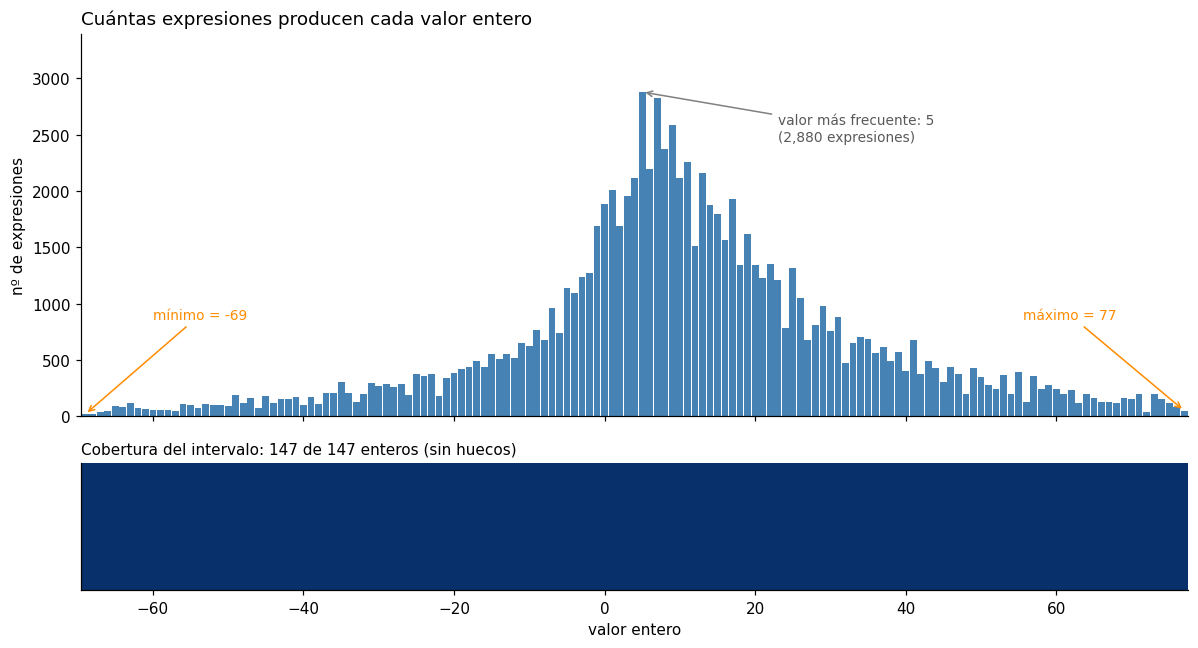

La distribución está centrada cerca de cero y decae hacia los extremos:
el valor 5 se obtiene de 2,880 formas distintas,
mientras que los extremos -69 y 77 solo admiten 16 y 48 expresiones respectivamente.
Esto anticipa que los valores extremos serán los más costosos de encontrar
mediante búsqueda dirigida (pregunta 6).


In [ ]:
# Figura 2 · Distribución de los valores alcanzables y cobertura del intervalo
frecuencias = {}
for cifras in permutations(CIFRAS, K_CIFRAS):
    for ops in permutations(OPERADORES, K_OPS):
        v = evaluar(cifras, ops)
        if v.is_integer():
            frecuencias[int(v)] = frecuencias.get(int(v), 0) + 1

xs = list(range(MINIMO, MAXIMO + 1))
ys = [frecuencias.get(x, 0) for x in xs]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6),
                               gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.bar(xs, ys, color=AZUL, width=0.9)
ax1.set_ylabel('nº de expresiones')
ax1.set_title('Cuántas expresiones producen cada valor entero', loc='left')
ax1.set_ylim(0, max(ys) * 1.18)
for x, dx, ha, etiq in ((MINIMO, 9, 'left', f'mínimo = {MINIMO}'),
                        (MAXIMO, -9, 'right', f'máximo = {MAXIMO}')):
    ax1.annotate(etiq, xy=(x, frecuencias[x]), xytext=(x + dx, max(ys) * 0.30),
                 ha=ha, fontsize=9, color=NARANJA,
                 arrowprops=dict(arrowstyle='->', color=NARANJA))
mas_frecuente = max(frecuencias, key=frecuencias.get)
ax1.annotate(f'valor más frecuente: {mas_frecuente}\n({frecuencias[mas_frecuente]:,} expresiones)',
             xy=(mas_frecuente, frecuencias[mas_frecuente]),
             xytext=(mas_frecuente + 18, max(ys) * 0.85), fontsize=9, color='0.35',
             arrowprops=dict(arrowstyle='->', color='0.5'))

ax2.imshow([[1 if frecuencias.get(x, 0) else 0 for x in xs]], aspect='auto',
           cmap='Blues', vmin=0, vmax=1, extent=[MINIMO - .5, MAXIMO + .5, 0, 1])
ax2.set_yticks([])
ax2.set_xlabel('valor entero')
ax2.set_title(f'Cobertura del intervalo: {len(VALORES)} de {MAXIMO-MINIMO+1} enteros '
              f'(sin huecos)', loc='left', fontsize=10)
plt.tight_layout(); plt.show()

print(f"La distribución está centrada cerca de cero y decae hacia los extremos:")
print(f"el valor {mas_frecuente} se obtiene de {frecuencias[mas_frecuente]:,} formas distintas,")
print(f"mientras que los extremos {MINIMO} y {MAXIMO} solo admiten "
      f"{frecuencias[MINIMO]} y {frecuencias[MAXIMO]} expresiones respectivamente.")
print("Esto anticipa que los valores extremos serán los más costosos de encontrar")
print("mediante búsqueda dirigida (pregunta 6).")

---
## 4. Diseña un algoritmo para resolver el problema por fuerza bruta

**Respuesta:**

El algoritmo por fuerza bruta genera **todas** las expresiones válidas, evalúa cada una y acumula los
resultados enteros en un conjunto.

```
ALGORITMO fuerza_bruta:
    alcanzados <- conjunto vacío
    PARA CADA variación de 5 cifras distintas de {1..9}:        # P(9,5) = 15.120
        PARA CADA permutación de los 4 operadores:              # 4! = 24
            construir la expresión d1 op1 d2 op2 d3 op3 d4 op4 d5
            v <- evaluar(expresión)
            SI v es entero:
                añadir v a alcanzados
    DEVOLVER alcanzados
```

**Sobre la división por cero.** No es necesario capturar `ZeroDivisionError`: el divisor es siempre
una cifra suelta del conjunto $\{1,\dots,9\}$, que no incluye el cero. Por eso el pseudocódigo no
contempla ese caso.

**Sobre la generación.** El uso de `itertools.permutations(CIFRAS, 5)` produce directamente las
variaciones sin repetición, de modo que las restricciones se satisfacen **por construcción**: no se
genera ninguna expresión inválida que haya que descartar después. Esta es la diferencia frente a un
enfoque con `itertools.product`, que generaría los 15 116 544 casos del conteo sin restricciones y
obligaría a filtrar el 97,6 %.

**Correctitud.** El recorrido es exhaustivo, luego el conjunto devuelto es exactamente $V$. Esta
exhaustividad es lo que permite responder a la segunda pregunta del enunciado: solo habiendo
examinado todas las expresiones se puede afirmar que un valor **no** es alcanzable.

In [ ]:
# Pregunta 4 · Fuerza bruta

def fuerza_bruta(cifras_disp=CIFRAS, ops_disp=OPERADORES, k=K_CIFRAS):
    """Genera y evalúa todas las expresiones válidas.
    Devuelve (conjunto de valores enteros alcanzados, nº de expresiones evaluadas)."""
    alcanzados = set()
    evaluadas = 0
    for cifras in permutations(cifras_disp, k):
        for ops in permutations(ops_disp, k - 1):
            v = evaluar(cifras, ops)
            evaluadas += 1
            if v.is_integer():
                alcanzados.add(int(v))
    return alcanzados, evaluadas


t0 = time.perf_counter()
ALCANZABLES, n_evaluadas = fuerza_bruta()
t_fb = time.perf_counter() - t0

print(f"Expresiones evaluadas    : {n_evaluadas:,}")
print(f"Coincide con P(9,5) x 4! : {n_evaluadas == con_restricciones}")
print(f"Tiempo                   : {t_fb:.2f} s")
print()
print(f"Valor mínimo             : {min(ALCANZABLES)}")
print(f"Valor máximo             : {max(ALCANZABLES)}")
print(f"Valores enteros distintos: {len(ALCANZABLES)}")

Expresiones evaluadas    : 362,880
Coincide con P(9,5) x 4! : True
Tiempo                   : 0.36 s

Valor mínimo             : -69
Valor máximo             : 77
Valores enteros distintos: 147


### Respuesta a las dos preguntas del enunciado

**1. ¿Qué valor máximo y mínimo se pueden obtener según las condiciones del problema?**

El valor mínimo es **−69** y el máximo es **77**, justificados en el análisis de la pregunta 3.

**2. ¿Es posible encontrar todos los valores enteros posibles entre dicho mínimo y máximo?**

**Sí.** El intervalo $[-69, 77]$ contiene $77-(-69)+1 = 147$ enteros y el algoritmo alcanza
exactamente 147 valores distintos. Como el conjunto obtenido está contenido en el intervalo y tiene
su mismo cardinal, ambos conjuntos coinciden.

El argumento por conteo es concluyente, pero conviene no depender de él: un error que introdujera un
valor fuera del intervalo lo invalidaría silenciosamente. La comprobación directa, buscando huecos uno
a uno, se realiza a continuación.

In [ ]:
# Comprobación directa de que no falta ningún entero intermedio
intervalo = list(range(min(ALCANZABLES), max(ALCANZABLES) + 1))
faltantes = [x for x in intervalo if x not in ALCANZABLES]
sobrantes = [x for x in ALCANZABLES if x not in intervalo]

print(f"Enteros en el intervalo [{min(ALCANZABLES)}, {max(ALCANZABLES)}] : {len(intervalo)}")
print(f"Enteros efectivamente alcanzados                  : {len(ALCANZABLES)}")
print(f"Enteros del intervalo NO alcanzables              : "
      f"{faltantes if faltantes else 'ninguno'}")
print(f"Valores alcanzados FUERA del intervalo            : "
      f"{sobrantes if sobrantes else 'ninguno'}")
print()
print(f"CONCLUSIÓN: se obtienen todos los enteros entre {min(ALCANZABLES)} "
      f"y {max(ALCANZABLES)}, ambos incluidos.")

Enteros en el intervalo [-69, 77] : 147
Enteros efectivamente alcanzados                  : 147
Enteros del intervalo NO alcanzables              : ninguno
Valores alcanzados FUERA del intervalo            : ninguno

CONCLUSIÓN: se obtienen todos los enteros entre -69 y 77, ambos incluidos.


---
## 5. Calcula la complejidad del algoritmo por fuerza bruta

**Respuesta:**

Para que el análisis sea informativo hay que expresarlo **en función del tamaño del problema** y no
de las cifras concretas del enunciado. Se generaliza así:

- $n$ : número de cifras disponibles ($n=9$)
- $k$ : número de cifras que intervienen en cada expresión ($k=5$)
- $m$ : número de operadores disponibles ($m=4$), de los que se usan $k-1$

### Complejidad temporal

El número de expresiones generadas es

$$N(n,k,m) \;=\; P(n,k)\cdot P(m,k-1) \;=\; \frac{n!}{(n-k)!}\cdot\frac{m!}{(m-k+1)!}$$

y cada una se evalúa en $k-1$ operaciones aritméticas de coste constante, más una inserción en el
conjunto, que es $O(1)$ amortizada. Por tanto:

$$\boxed{\;T(n,k,m) \;=\; O\!\left(k \cdot P(n,k)\cdot P(m,k-1)\right)\;}$$

Para $n=9,\ k=5,\ m=4$ se recupera $N = 15\,120 \times 24 = 362\,880$ expresiones.

**Orden de crecimiento.** Con $m$ fijo y $k$ fijo, $P(n,k)\in\Theta(n^k)$, es decir **polinómico de
grado $k$** en el número de cifras. Pero si crece $k$ junto con $n$ (por ejemplo, usar todas las
cifras disponibles, $k=n$), entonces $P(n,n)=n!$ y el crecimiento pasa a ser **factorial**. Es decir:
el problema es tratable por fuerza bruta *porque $k=5$ es pequeño y está fijado*, no porque el
problema sea fácil en general.

### Complejidad espacial

El conjunto `alcanzados` almacena a lo sumo tantos elementos como valores enteros distintos existan,
que están acotados por la amplitud del recorrido:

$$|V| \;\le\; \max V - \min V + 1$$

Como el término dominante de una expresión es un producto de cifras, esa amplitud crece como
$O(n^{\lceil k/2 \rceil})$; para $k=5$ y los datos del enunciado, $O(n^2)$. Se obtiene por tanto:

$$S(n,k) \;=\; O\!\left(n^{2}\right) \quad\text{para } k=5$$

que para $n=9$ son los 147 valores observados. Conviene subrayar que **no** es $O(N)$: el número de
expresiones evaluadas (362 880) y el número de valores almacenados (147) difieren en tres órdenes de
magnitud, porque el conjunto elimina los duplicados. Tampoco es $O(1)$, ya que depende de $n$.

Crecimiento en n (k=5 fijo): polinómico de grado 5
 n cifras disponibles  expresiones N(n,5,4)
                    5                  2880
                    6                 17280
                    7                 60480
                    8                161280
                    9                362880
                   10                725760
                   11               1330560
                   12               2280960

Crecimiento en k (n=9 fijo): limitado por m=4 operadores
 k cifras usadas  expresiones N(9,k,4)
               2                   288
               3                  6048
               4                 72576
               5                362880


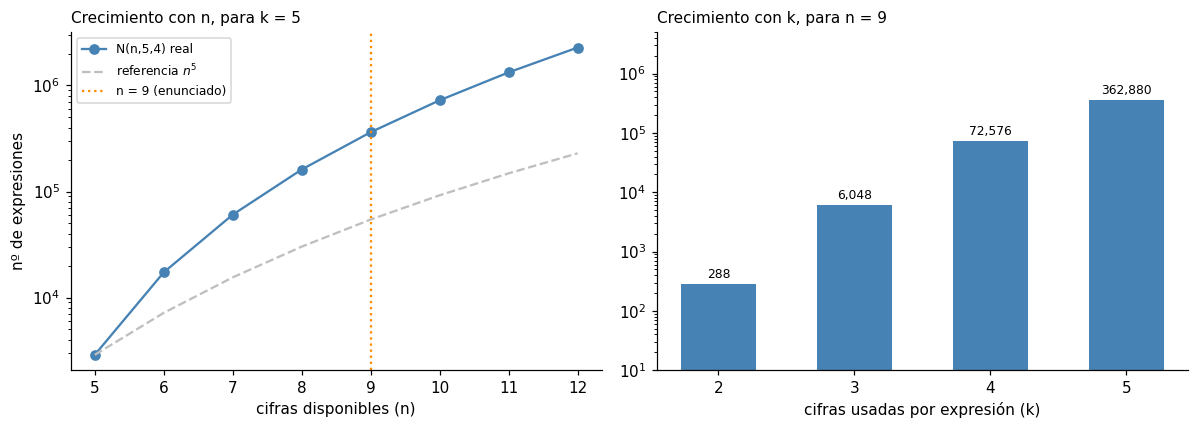

El caso del enunciado (n=9, k=5) queda holgadamente dentro de lo tratable;
con 12 cifras disponibles el espacio se multiplica por más de 20.


In [ ]:
# Pregunta 5 · Verificación empírica del modelo de complejidad
def n_expresiones(n, k, m):
    """N(n,k,m) = P(n,k) * P(m,k-1)"""
    if k - 1 > m or k > n:
        return 0
    return variaciones(n, k) * variaciones(m, k - 1)

filas = []
for n in range(5, 13):
    filas.append([n, n_expresiones(n, K_CIFRAS, len(OPERADORES))])
tabla_n = pd.DataFrame(filas, columns=['n cifras disponibles', 'expresiones N(n,5,4)'])

filas_k = []
for k in range(2, 6):
    filas_k.append([k, n_expresiones(9, k, 4)])
tabla_k = pd.DataFrame(filas_k, columns=['k cifras usadas', 'expresiones N(9,k,4)'])

print('Crecimiento en n (k=5 fijo): polinómico de grado 5')
print(tabla_n.to_string(index=False))
print()
print('Crecimiento en k (n=9 fijo): limitado por m=4 operadores')
print(tabla_k.to_string(index=False))

# Figura 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ns = tabla_n['n cifras disponibles']
ax1.plot(ns, tabla_n['expresiones N(n,5,4)'], 'o-', color=AZUL, label='N(n,5,4) real')
ref = tabla_n['expresiones N(n,5,4)'].iloc[0] * (ns / ns.iloc[0]) ** 5
ax1.plot(ns, ref, '--', color=GRIS, label='referencia $n^5$')
ax1.axvline(9, color=NARANJA, ls=':', label='n = 9 (enunciado)')
ax1.set_yscale('log'); ax1.set_xlabel('cifras disponibles (n)')
ax1.set_ylabel('nº de expresiones'); ax1.legend(fontsize=8)
ax1.set_title('Crecimiento con n, para k = 5', loc='left', fontsize=10)

ks = tabla_k['k cifras usadas']
ax2.bar(ks, tabla_k['expresiones N(9,k,4)'], color=AZUL, width=0.55)
for x, v in zip(ks, tabla_k['expresiones N(9,k,4)']):
    ax2.text(x, v * 1.25, f"{v:,}", ha='center', fontsize=8)
ax2.set_yscale('log'); ax2.set_ylim(10, 5e6)
ax2.set_xticks(list(ks)); ax2.set_xlabel('cifras usadas por expresión (k)')
ax2.set_title('Crecimiento con k, para n = 9', loc='left', fontsize=10)
plt.tight_layout(); plt.show()

print('El caso del enunciado (n=9, k=5) queda holgadamente dentro de lo tratable;')
print('con 12 cifras disponibles el espacio se multiplica por más de 20.')

---
## 6. (\*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

**Respuesta:**

Antes de proponer una mejora es necesario separar **dos objetivos distintos**, porque no admiten el
mismo tipo de optimización.

### Consideración previa: qué familias de algoritmos son aplicables

Como se argumentó en la pregunta 3, la pregunta *"¿es posible obtener todos los enteros del
intervalo?"* solo puede responderse con un método **completo**: para afirmar que un valor no es
alcanzable hay que haber descartado todas las expresiones que podrían producirlo.

Esto excluye de entrada las técnicas **voraces** y las de **búsqueda local aleatoria**. Una heurística
voraz construiría la expresión eligiendo en cada paso la cifra u operador que más se acerque al
objetivo, pero la precedencia de operadores hace que esa decisión local no sea informativa: colocar
un `*` puede parecer óptimo y resultar desastroso si después obliga a dividir. Y una búsqueda local
o aleatoria podría encontrar valores, pero **nunca podría demostrar que un valor falta**, que es
justamente lo que pregunta el enunciado. Ambas familias quedan por tanto descartadas por razones de
adecuación al problema, no de rendimiento.

El diseño se orienta, en consecuencia, hacia técnicas **exactas**: mejora de la evaluación y
**vuelta atrás** (capítulo 5 del material de la asignatura).

---

### Objetivo A — Obtener el conjunto completo de valores alcanzables

**Mejora aplicada: eliminar `eval()` y evaluar en una sola pasada.** Es el cambio de representación
descrito en la pregunta 2: se sustituye la construcción de una cadena y su compilación por dos
acumuladores (`suma` y `termino`) que respetan la precedencia con cuatro operaciones aritméticas.

**Argumentación honesta sobre la mejora.** El número de expresiones sigue siendo $N = 362\,880$, de
modo que **el orden de complejidad no cambia**: sigue siendo $O(k\cdot N)$. Lo que se reduce es el
trabajo por expresión, y la ganancia medida es de aproximadamente un **factor 10**.

Y conviene afirmarlo explícitamente: **para este objetivo no existe ninguna mejora de orden**, ni con
este ni con ningún otro algoritmo exacto. Responder que faltan o no faltan enteros exige examinar el
espacio completo, lo que constituye una **cota inferior del problema** y no una limitación de esta
implementación.

Por la misma razón se descartó una idea aparentemente atractiva: detener el recorrido al alcanzar 147
valores distintos. Ese 147 es precisamente el resultado que el algoritmo debe descubrir, de modo que
usarlo como criterio de parada sería un razonamiento circular.

---

### Objetivo B — Obtener una cantidad dada

El enunciado plantea también combinar las cifras *"para obtener una cantidad dada"*, como el ejemplo
`4+2-6/3*1 = 4`. Para este objetivo sí existe una mejora sustancial mediante **vuelta atrás**:

1. **Construcción incremental.** La expresión se construye cifra a cifra, descendiendo por un árbol
   de búsqueda en el que cada nivel añade un operador y una cifra.
2. **Reutilización del prefijo.** El estado `(suma, termino)` se transmite hacia abajo, de modo que un
   prefijo de 3 cifras se evalúa **una sola vez** y sirve para las $P(6,2)\times 2! = 60$ expresiones
   que lo continúan. La fuerza bruta repite ese cálculo 60 veces.
3. **Corte al encontrar el objetivo.** En cuanto una rama alcanza el valor buscado se abandona la
   búsqueda.

Este corte sí es legítimo, a diferencia del criterio por conteo descartado en el objetivo A: el
criterio es *"se ha encontrado lo que se buscaba"* y no requiere conocer nada del problema por
adelantado.

In [ ]:
# Pregunta 6 · Objetivo A — recorrido completo sin eval()
# (la comparación de tiempos ya se realizó en la pregunta 2)
print(f"Recorrido completo con eval()          : {t_eval:5.2f} s")
print(f"Recorrido completo con evaluación directa: {t_dir:5.2f} s")
print(f"Factor de mejora medido                : x{FACTOR_MEJORA:.1f}")
print(f"Mismos resultados en ambos casos       : {conj_eval == conj_dir}")
print()
print("El orden de complejidad no cambia: ambos recorren las 362.880 expresiones.")
print("La mejora es del factor constante, no del orden de crecimiento.")

Recorrido completo con eval()          :  5.63 s
Recorrido completo con evaluación directa:  0.34 s
Factor de mejora medido                : x16.6
Mismos resultados en ambos casos       : True

El orden de complejidad no cambia: ambos recorren las 362.880 expresiones.
La mejora es del factor constante, no del orden de crecimiento.


In [ ]:
# Pregunta 6 · Objetivo B — vuelta atrás con corte al encontrar el objetivo

def buscar_objetivo(objetivo, cifras_disp=CIFRAS, ops_disp=OPERADORES, k=K_CIFRAS):
    """Busca UNA expresión cuyo valor sea `objetivo`, construyéndola cifra a cifra.
    Arrastra (suma, termino) para no reevaluar el prefijo en cada rama.
    Devuelve (expresión o None, nodos explorados)."""
    solucion = [None]
    nodos = [0]

    def bt(pos, suma, termino, cifras_usadas, ops_usados, expr):
        if solucion[0] is not None:
            return
        nodos[0] += 1
        if pos == k:                                  # expresión completa
            if suma + termino == objetivo:
                solucion[0] = expr
            return
        for d in cifras_disp:
            if d in cifras_usadas:
                continue                              # (R1) cifras sin repetir
            for idx, op in enumerate(ops_disp):
                if idx in ops_usados:
                    continue                          # (R2) operadores sin repetir
                if op == '*':   ns, nt = suma, termino * d
                elif op == '/': ns, nt = suma, termino / d
                elif op == '+': ns, nt = suma + termino, float(d)
                else:           ns, nt = suma + termino, -float(d)
                bt(pos + 1, ns, nt, cifras_usadas | {d}, ops_usados | {idx},
                   expr + op + str(d))
                if solucion[0] is not None:
                    return

    for primera in cifras_disp:
        bt(1, 0.0, float(primera), {primera}, set(), str(primera))
        if solucion[0] is not None:
            break
    return solucion[0], nodos[0]


# Nodos del árbol completo: un nivel por cifra colocada
NODOS_ARBOL = sum(variaciones(9, i) * variaciones(4, i - 1) for i in range(1, K_CIFRAS + 1))
print(f"Nodos del árbol de búsqueda completo: {NODOS_ARBOL:,}")
print(f"(frente a las {con_restricciones:,} expresiones completas de la fuerza bruta)")
print()
print(f"{'objetivo':>9}  {'expresión':<12} {'nodos':>9}  {'% del árbol':>12}")
print('-' * 48)
for objetivo in [4, 0, MAXIMO, MINIMO, 500]:
    expr, nodos = buscar_objetivo(objetivo)
    print(f"{objetivo:>9}  {expr if expr else 'no existe':<12} {nodos:>9,}  "
          f"{100*nodos/NODOS_ARBOL:>11.2f}%")
print()
print("El objetivo 4 del enunciado se resuelve explorando el 0,4 % del árbol.")
print("Los valores extremos son los más costosos, coherentemente con la figura 2.")

Nodos del árbol de búsqueda completo: 441,801
(frente a las 362,880 expresiones completas de la fuerza bruta)

 objetivo  expresión        nodos   % del árbol
------------------------------------------------
        4  1-2*3/6+4        1,642         0.37%
        0  1+2/3*6-5          182         0.04%
       77  7/1-2+8*9      299,266        67.74%
      -69  1+4/2-8*9       12,475         2.82%
      500  no existe      441,801       100.00%

El objetivo 4 del enunciado se resuelve explorando el 0,4 % del árbol.
Los valores extremos son los más costosos, coherentemente con la figura 2.


### Sobre la conveniencia de añadir poda (ramificación y poda)

Una extensión natural del algoritmo anterior es añadir **poda por cotas**: en cada nodo se estima el
intervalo $[L, U]$ de valores todavía alcanzables y, si el objetivo queda fuera, se abandona la rama
sin explorarla.

La intuición sugiere que esto debe mejorar siempre. **No es así**, y merece un análisis cuidadoso,
porque la poda introduce dos riesgos que no son evidentes.

**Riesgo 1: el coste de la cota puede superar lo que ahorra.** Evaluar un nodo cuesta aquí apenas
cuatro operaciones aritméticas, del orden de 1 µs. Ese es todo el presupuesto disponible para
calcular la cota. La regla es sencilla:

> La poda compensa si, y solo si, el **factor de reducción de nodos supera al factor de
> encarecimiento por nodo**.

**Riesgo 2: una cota mal diseñada puede eliminar soluciones válidas.** Una cota es *admisible* si
nunca descarta una rama que contenga solución. Si no lo es, la búsqueda puede recorrer más nodos —al
descartar la solución más cercana y seguir buscando— e incluso informar erróneamente de que un valor
alcanzable no existe.

Ambos riesgos se miden a continuación sobre los 147 objetivos alcanzables.

In [ ]:
# Poda por cotas: implementación y medición de los dos riesgos
BLOQUE_MAX = 72.0        # mayor bloque multiplicativo posible: 8*9

def buscar_objetivo_podado(objetivo, cifras_disp=CIFRAS, ops_disp=OPERADORES, k=K_CIFRAS):
    """Igual que buscar_objetivo(), pero abandonando la rama cuando el objetivo
    queda fuera del intervalo [L, U] estimado de valores alcanzables."""
    solucion = [None]; nodos = [0]; podadas = [0]

    def cotas(suma, termino, cifras_usadas, ops_usados):
        libres = sorted([d for d in cifras_disp if d not in cifras_usadas], reverse=True)
        n_mult = sum(1 for i in (2, 3) if i not in ops_usados)   # '*' y '/' pendientes
        n_suma = 1 if 0 not in ops_usados else 0                 # '+' pendiente
        n_resta = 1 if 1 not in ops_usados else 0                # '-' pendiente
        factor = 1.0
        for i in range(min(n_mult, len(libres))):
            factor *= libres[i]
        candidatos = [termino, termino * factor,
                      termino / libres[-1] if libres else termino]
        return (suma + min(candidatos) - BLOQUE_MAX * n_resta,
                suma + max(candidatos) + BLOQUE_MAX * n_suma)

    def bt(pos, suma, termino, cifras_usadas, ops_usados, expr):
        if solucion[0] is not None: return
        nodos[0] += 1
        if pos == k:
            if suma + termino == objetivo: solucion[0] = expr
            return
        L, U = cotas(suma, termino, cifras_usadas, ops_usados)
        if objetivo < L - 1e-9 or objetivo > U + 1e-9:
            podadas[0] += 1
            return                                            # PODA
        for d in cifras_disp:
            if d in cifras_usadas: continue
            for idx, op in enumerate(ops_disp):
                if idx in ops_usados: continue
                if op == '*':   ns, nt = suma, termino * d
                elif op == '/': ns, nt = suma, termino / d
                elif op == '+': ns, nt = suma + termino, float(d)
                else:           ns, nt = suma + termino, -float(d)
                bt(pos + 1, ns, nt, cifras_usadas | {d}, ops_usados | {idx},
                   expr + op + str(d))
                if solucion[0] is not None: return

    for primera in cifras_disp:
        bt(1, 0.0, float(primera), {primera}, set(), str(primera))
        if solucion[0] is not None: break
    return solucion[0], nodos[0], podadas[0]


# --- Medición sobre los 147 objetivos alcanzables ---
objetivos = sorted(ALCANZABLES)
t0 = time.perf_counter()
sin_poda = [buscar_objetivo(x) for x in objetivos]
t_sin = time.perf_counter() - t0

t0 = time.perf_counter()
con_poda = [buscar_objetivo_podado(x) for x in objetivos]
t_con = time.perf_counter() - t0

nodos_sin = sum(n for _, n in sin_poda)
nodos_con = sum(n for _, n, _ in con_poda)

print(f"{'':<26}{'sin poda':>14}{'con poda':>14}")
print('-' * 54)
print(f"{'objetivos resueltos':<26}{sum(1 for e,_ in sin_poda if e):>14}"
      f"{sum(1 for e,_,_ in con_poda if e):>14}")
print(f"{'nodos totales':<26}{nodos_sin:>14,}{nodos_con:>14,}")
print(f"{'nodos medios por objetivo':<26}{nodos_sin//len(objetivos):>14,}"
      f"{nodos_con//len(objetivos):>14,}")
print(f"{'tiempo total (s)':<26}{t_sin:>14.2f}{t_con:>14.2f}")
print(f"{'coste por nodo (µs)':<26}{1e6*t_sin/nodos_sin:>14.2f}{1e6*t_con/nodos_con:>14.2f}")
print()
print(f"Reducción de nodos : {100*(nodos_sin-nodos_con)/nodos_sin:5.1f} %")
print(f"Reducción de tiempo: {100*(t_sin-t_con)/t_sin:5.1f} %")
print(f"Factor de reducción de nodos      : x{nodos_sin/nodos_con:.2f}")
print(f"Factor de encarecimiento por nodo : x{(t_con/nodos_con)/(t_sin/nodos_sin):.2f}")
print()
print("La poda compensa en conjunto porque el primer factor supera al segundo.")

                                sin poda      con poda
------------------------------------------------------
objetivos resueltos                  147           147
nodos totales                  4,892,142     1,696,011
nodos medios por objetivo         33,279        11,537
tiempo total (s)                    8.33          5.29
coste por nodo (µs)                 1.70          3.12

Reducción de nodos :  65.3 %
Reducción de tiempo:  36.5 %
Factor de reducción de nodos      : x2.88
Factor de encarecimiento por nodo : x1.83

La poda compensa en conjunto porque el primer factor supera al segundo.


In [ ]:
# Riesgo 2 · ¿Es admisible la cota? Contraste de las soluciones halladas
distintas = []
mas_nodos = []
for (e1, n1), (e2, n2, _), obj in zip(sin_poda, con_poda, objetivos):
    if e2 is None:
        distintas.append((obj, e1, 'NO ENCONTRADA'))
    else:
        if e1 != e2:
            distintas.append((obj, e1, e2))
        if n2 > n1:
            mas_nodos.append((obj, n1, n2))

print("La poda solo puede ELIMINAR subárboles. Por tanto, si cambia la primera")
print("solución hallada, es porque se ha cortado una rama que sí contenía solución:")
print("la cota NO es admisible.")
print()
print(f"Objetivos con solución distinta: {len(distintas)} de {len(objetivos)}")
print(f"{'objetivo':>9}  {'sin poda':<12} {'con poda':<12}")
print('-' * 38)
for obj, a, b in distintas[:6]:
    print(f"{obj:>9}  {a:<12} {b:<12}")
print()
print(f"Objetivos en los que la poda explora MÁS nodos: {len(mas_nodos)}")
for obj, n1, n2 in mas_nodos:
    print(f"  objetivo {obj:>4}: {n1:>7,} -> {n2:>7,} nodos")
print()
todas_validas = all(e is None or eval(e) == o
                    for (e, _, _), o in zip(con_poda, objetivos))
print(f"¿Todas las expresiones devueltas con poda son correctas?: {'Si' if todas_validas else 'No'}")
print()
print("\nCONCLUSIÓN: en esta instancia no se ha perdido ningún objetivo, pero eso es")
print("una circunstancia favorable, no una garantía. Una cota no admisible puede")
print("informar de que un valor alcanzable no existe. Antes de adoptar una poda hay")
print("que demostrar su admisibilidad, no solo medir que va más rápido.")

La poda solo puede ELIMINAR subárboles. Por tanto, si cambia la primera
solución hallada, es porque se ha cortado una rama que sí contenía solución:
la cota NO es admisible.

Objetivos con solución distinta: 15 de 147
 objetivo  sin poda     con poda    
--------------------------------------
      -44  1-6*8+9/3    1+9/3-6*8   
      -38  1-6*7+9/3    1+9/3-6*7   
      -33  1-4*9+6/3    1+6/3-4*9   
      -29  1-4*8+6/3    1+6/3-4*8   
      -26  1-5*6+9/3    1+9/3-5*6   
      -25  1-4*7+6/3    1-5*6+8/2   

Objetivos en los que la poda explora MÁS nodos: 3
  objetivo  -26:  20,738 ->  21,992 nodos
  objetivo    1:       6 ->      20 nodos
  objetivo   28:  19,204 ->  22,355 nodos

¿Todas las expresiones devueltas con poda son correctas?: Si


CONCLUSIÓN: en esta instancia no se ha perdido ningún objetivo, pero eso es
una circunstancia favorable, no una garantía. Una cota no admisible puede
informar de que un valor alcanzable no existe. Antes de adoptar una poda hay
que demostrar su

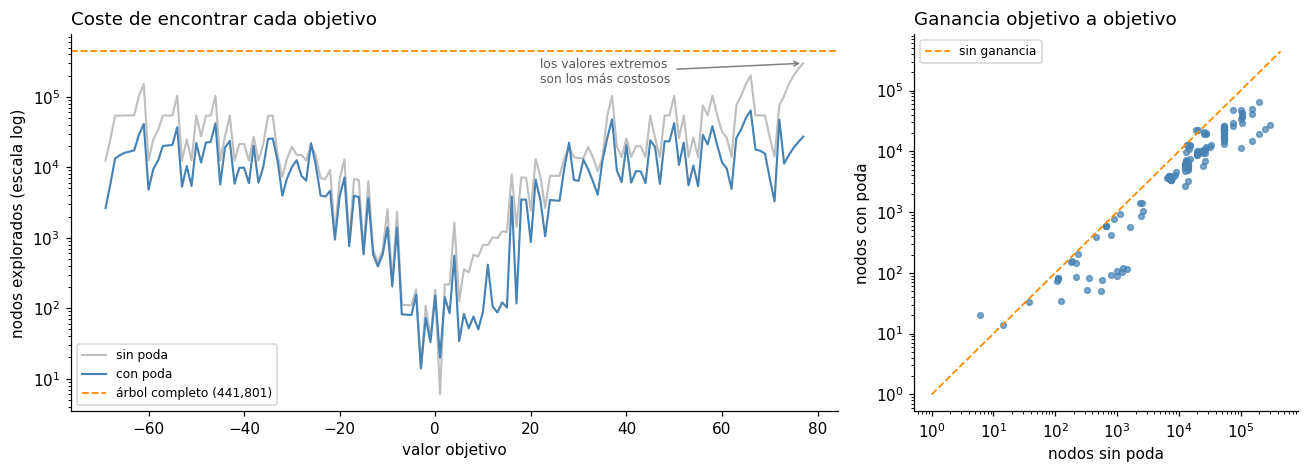

La poda reduce los nodos en 143 de los 147 objetivos (puntos por debajo de la diagonal).
Los puntos sobre o por encima de la diagonal son los casos en que no aporta
nada o incluso perjudica, que es el riesgo analizado más arriba.


In [ ]:
# Figura 4 · Coste de la búsqueda por objetivo, con y sin poda
n_sin_lista = [n for _, n in sin_poda]
n_con_lista = [n for _, n, _ in con_poda]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4),
                               gridspec_kw={'width_ratios': [2, 1]})

ax1.plot(objetivos, n_sin_lista, '-', color=GRIS, linewidth=1.4, label='sin poda')
ax1.plot(objetivos, n_con_lista, '-', color=AZUL, linewidth=1.4, label='con poda')
ax1.axhline(NODOS_ARBOL, color=NARANJA, ls='--', linewidth=1.2,
            label=f'árbol completo ({NODOS_ARBOL:,})')
ax1.set_yscale('log')
ax1.set_xlabel('valor objetivo')
ax1.set_ylabel('nodos explorados (escala log)')
ax1.set_title('Coste de encontrar cada objetivo', loc='left')
ax1.legend(fontsize=8)

peores = [(o, n) for o, n in zip(objetivos, n_sin_lista)]
peores.sort(key=lambda r: -r[1])
ax1.annotate(f'los valores extremos\nson los más costosos',
             xy=(peores[0][0], peores[0][1]),
             xytext=(peores[0][0] - 55, NODOS_ARBOL * 0.35), fontsize=8, color='0.35',
             arrowprops=dict(arrowstyle='->', color='0.5'))

ax2.scatter(n_sin_lista, n_con_lista, s=14, color=AZUL, alpha=0.7)
lim = [1, NODOS_ARBOL]
ax2.plot(lim, lim, '--', color=NARANJA, linewidth=1.2, label='sin ganancia')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('nodos sin poda'); ax2.set_ylabel('nodos con poda')
ax2.set_title('Ganancia objetivo a objetivo', loc='left')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

por_debajo = sum(1 for a, b in zip(n_sin_lista, n_con_lista) if b < a)
print(f"La poda reduce los nodos en {por_debajo} de los {len(objetivos)} objetivos "
      f"(puntos por debajo de la diagonal).")
print("Los puntos sobre o por encima de la diagonal son los casos en que no aporta")
print("nada o incluso perjudica, que es el riesgo analizado más arriba.")

---
## 7. (\*)Calcula la complejidad del algoritmo

**Respuesta:**

Se mantiene la notación de la pregunta 5: $n$ cifras disponibles, $k$ cifras por expresión, $m$
operadores, y $N = P(n,k)\cdot P(m,k-1)$.

### Objetivo A — recorrido completo con evaluación directa

$$T_A = O\!\left(k\cdot P(n,k)\cdot P(m,k-1)\right) \qquad
S_A = O\!\left(n^{2}\right)\ \text{(para } k=5)$$

**La misma que la fuerza bruta.** La mejora es del factor constante, medido en torno a ×10, no del
orden de crecimiento. Como se argumentó, para este objetivo no existe mejora de orden posible.

### Objetivo B — vuelta atrás para una cantidad dada

El árbol de búsqueda tiene un nivel por cifra colocada. En el nivel $i$ hay $P(n,i)\cdot P(m,i-1)$
nodos, luego el total es

$$\mathcal{N}(n,k,m) \;=\; \sum_{i=1}^{k} P(n,i)\cdot P(m,i-1)
\;=\; 9 + 288 + 6\,048 + 72\,576 + 362\,880 \;=\; 441\,801 \text{ nodos}$$

Cada nodo cuesta $O(1)$, porque arrastra `(suma, termino)` en lugar de reevaluar la expresión
completa. Distinguiendo casos:

| Caso | Situación | Complejidad |
|---|---|---|
| Mejor caso | la primera rama alcanza el objetivo | $O(k)$ |
| Caso medio | el objetivo existe | $O(M)$, con $M \ll \mathcal{N}$ medido |
| Peor caso | el objetivo no existe | $O(\mathcal{N})$, se agota el árbol |

**Espacio:** $O(k)$ por la profundidad de la recursión y los conjuntos de elementos usados, es decir
$O(1)$ para $k$ fijo. A diferencia del objetivo A, este algoritmo no necesita almacenar el conjunto de
resultados.

**Es importante señalar que el peor caso no mejora a la fuerza bruta.** Cuando el objetivo no
pertenece a $V$ hay que agotar el árbol completo. La mejora se produce en el caso medio, y es
consecuencia de dos factores: la reutilización de prefijos y el corte al encontrar la solución.

### Efecto de la poda sobre la complejidad

La poda **no altera el orden de complejidad**: en el peor caso sigue siendo $O(\mathcal{N})$. Su
efecto es sobre el factor constante y sobre el caso medio, y admite el análisis cuantitativo
siguiente, con $c_1$ el coste de un nodo sin poda, $c_2$ el coste con poda y $\rho$ el factor de
reducción de nodos:

$$\text{la poda compensa} \iff \rho \;>\; \frac{c_2}{c_1}$$

Los valores medidos sobre los 147 objetivos aparecen en la celda de resultados de la pregunta 6.
Cuando el objetivo se encuentra en pocos nodos, $\rho \approx 1$ y la desigualdad no se cumple: la
poda es contraproducente. Este es el motivo por el que en una fracción apreciable de los objetivos el
tiempo con poda es superior.

### Resumen comparativo

| Algoritmo | Objetivo | Tiempo | Espacio |
|---|---|---|---|
| Fuerza bruta con `eval()` | conjunto completo | $O(k\,N)$ | $O(n^2)$ |
| Evaluación directa | conjunto completo | $O(k\,N)$, ×10 más rápida | $O(n^2)$ |
| Vuelta atrás con corte | una cantidad dada | $O(M)$ medio, $O(\mathcal{N})$ peor | $O(1)$ |
| Vuelta atrás con poda | una cantidad dada | $O(\mathcal{N})$ peor; medio mejor solo si $\rho > c_2/c_1$ | $O(1)$ |

In [ ]:
# Pregunta 7 · Verificación del recuento de nodos del árbol
print(f"{'nivel i':>8} {'nodos P(9,i)·P(4,i-1)':>24}")
print('-' * 34)
total = 0
for i in range(1, K_CIFRAS + 1):
    nodos_nivel = variaciones(9, i) * variaciones(4, i - 1)
    total += nodos_nivel
    print(f"{i:>8} {nodos_nivel:>24,}")
print('-' * 34)
print(f"{'TOTAL':>8} {total:>24,}")
print()
print(f"Coincide con el contador empírico del árbol completo: "
      f"{total == buscar_objetivo(500)[1]}")
print("(el objetivo 500 no es alcanzable, luego agota el árbol entero)")

 nivel i    nodos P(9,i)·P(4,i-1)
----------------------------------
       1                        9
       2                      288
       3                    6,048
       4                   72,576
       5                  362,880
----------------------------------
   TOTAL                  441,801

Coincide con el contador empírico del árbol completo: True
(el objetivo 500 no es alcanzable, luego agota el árbol entero)


---
## 8. Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

**Respuesta:**

### Qué constituye una "entrada" en este problema

Conviene precisarlo, porque no es evidente. Generar al azar cinco cifras y cuatro operadores **no
produce una entrada**: produce una *solución candidata*, un punto del espacio de búsqueda que el
algoritmo ya recorre por sí mismo. Evaluarla no ejercita ningún algoritmo.

Las entradas reales del problema son dos:

**Tipo 1 — El valor objetivo.** Es la *"cantidad dada"* del enunciado, el parámetro del algoritmo de
la pregunta 6. Un buen juego de pruebas debe incluir deliberadamente:

- objetivos **alcanzables**, elegidos al azar dentro de $V$;
- objetivos **no alcanzables** pero de magnitud plausible (fuera de $[-69, 77]$), que fuerzan el peor
  caso;
- objetivos **en la frontera** ($\min V$, $\max V$), que la figura 2 anticipa como los más costosos.

**Tipo 2 — La configuración del problema.** El enunciado fija $n=9$, $k=5$, $m=4$, pero el algoritmo
está escrito de forma paramétrica. Generar configuraciones alternativas permite verificar que sigue
siendo correcto y observar cómo crece el coste, lo que conecta directamente con la pregunta 11.

### Diseño del generador

El generador produce ambos tipos con una **semilla fija**, de modo que los resultados del notebook son
reproducibles. Para el tipo 2 se validan dos condiciones antes de devolver la configuración:
$k \le n$ (no se pueden usar más cifras de las disponibles) y $k-1 \le m$ (no se pueden usar más
operadores de los disponibles sin repetir).

In [ ]:
# Pregunta 8 · Generadores de datos de entrada

def generar_objetivos(n_alcanzables=6, n_inalcanzables=3, semilla=SEMILLA):
    """Tipo 1: valores objetivo. Mezcla casos alcanzables, no alcanzables y frontera."""
    rnd = random.Random(semilla)
    casos = []
    for x in rnd.sample(sorted(ALCANZABLES), n_alcanzables):
        casos.append((x, 'alcanzable'))
    for _ in range(n_inalcanzables):
        # fuera del intervalo [min, max], pero de magnitud plausible
        x = rnd.choice([rnd.randint(MAXIMO + 1, MAXIMO + 150),
                        rnd.randint(MINIMO - 150, MINIMO - 1)])
        casos.append((x, 'no alcanzable'))
    casos.append((MINIMO, 'frontera (mínimo)'))
    casos.append((MAXIMO, 'frontera (máximo)'))
    return casos


def generar_configuracion(semilla=None):
    """Tipo 2: variante del problema (cifras disponibles, cifras usadas, operadores).
    Valida k <= n y k-1 <= m antes de devolverla."""
    rnd = random.Random(semilla)
    n = rnd.randint(5, 9)                       # cuántas cifras hay disponibles
    m = rnd.randint(2, 4)                       # cuántos operadores se permiten
    k = rnd.randint(3, min(n, m + 1))           # cuántas cifras usa la expresión
    assert k <= n and k - 1 <= m, 'configuración inválida'
    cifras = sorted(rnd.sample(CIFRAS, n))
    ops = rnd.sample(OPERADORES, m)
    return {'cifras': cifras, 'operadores': ops, 'k': k, 'n': n, 'm': m}


OBJETIVOS_TEST = generar_objetivos()
CONFIGS_TEST = [generar_configuracion(SEMILLA + i) for i in range(5)]

print('TIPO 1 · valores objetivo generados')
print(pd.DataFrame(OBJETIVOS_TEST, columns=['objetivo', 'clase']).to_string(index=False))
print()
print('TIPO 2 · configuraciones alternativas del problema')
tabla_cfg = pd.DataFrame([{'cifras disponibles': ''.join(map(str, c['cifras'])),
                           'n': c['n'], 'operadores': ' '.join(c['operadores']),
                           'm': c['m'], 'k (cifras usadas)': c['k'],
                           'expresiones N(n,k,m)': f"{n_expresiones(c['n'], c['k'], c['m']):,}"}
                          for c in CONFIGS_TEST])
print(tabla_cfg.to_string(index=False))

TIPO 1 · valores objetivo generados
 objetivo             clase
      -39        alcanzable
       12        alcanzable
       59        alcanzable
       62        alcanzable
      -43        alcanzable
      -12        alcanzable
     -112     no alcanzable
      190     no alcanzable
     -191     no alcanzable
      -69 frontera (mínimo)
       77 frontera (máximo)

TIPO 2 · configuraciones alternativas del problema
cifras disponibles  n operadores  m  k (cifras usadas) expresiones N(n,k,m)
             45678  5      / * -  3                  3                  360
             12467  5      / + -  3                  3                  360
           1234689  7        * /  2                  3                  420
          23456789  8      / - *  3                  3                2,016
           1245679  7      - * /  3                  4                5,040


---
## 9. Aplica el algoritmo al juego de datos generado

**Respuesta:**

Se aplican los algoritmos de la pregunta 6 a los dos tipos de entrada generados.

**Experimento 1 — Vuelta atrás sobre los valores objetivo.** Para cada objetivo se mide la expresión
encontrada, el número de nodos explorados y el tiempo. El resultado se contrasta con el conjunto $V$
calculado por fuerza bruta, que actúa como **oráculo**: si el objetivo pertenece a $V$, el algoritmo
debe encontrarlo; si no, debe informar de que no existe. Es la validación de correctitud del
algoritmo.

**Experimento 2 — El algoritmo sobre configuraciones alternativas.** Se aplica la fuerza bruta
paramétrica a cada configuración generada, verificando que el número de expresiones evaluadas coincide
con la fórmula $N(n,k,m)$ de la pregunta 5 y observando cómo varían el rango y la densidad de valores
alcanzables.

In [ ]:
# Experimento 1 · Vuelta atrás sobre los valores objetivo generados
filas = []
for objetivo, clase in OBJETIVOS_TEST:
    t0 = time.perf_counter()
    expr, nodos = buscar_objetivo(objetivo)
    dt = time.perf_counter() - t0
    esperado = objetivo in ALCANZABLES
    correcto = (expr is not None) == esperado and (expr is None or eval(expr) == objetivo)
    filas.append({'objetivo': objetivo, 'clase': clase,
                  'expresión': expr if expr else '—',
                  'nodos': nodos, '% árbol': round(100*nodos/NODOS_ARBOL, 2),
                  'ms': round(dt*1000, 2),
                  'correcto': 'sí' if correcto else 'NO'})

exp1 = pd.DataFrame(filas)
print(exp1.to_string(index=False))
print()
print(f"Resultados correctos: {sum(exp1['correcto']=='sí')} de {len(exp1)}")
print()
print("Se aprecia la asimetría prevista en la pregunta 7: los objetivos no alcanzables")
print("agotan el 100 % del árbol, mientras que los alcanzables se resuelven en una")
print("fracción pequeña. Los objetivos frontera son los alcanzables más costosos.")

 objetivo             clase expresión  nodos  % árbol     ms correcto
      -39        alcanzable 1+4/2-6*7  12449     2.82  20.79       sí
       12        alcanzable 1+2*7-9/3   1014     0.23   1.55       sí
       59        alcanzable 2/1-6+7*9  54466    12.33  90.09       sí
       62        alcanzable 1-4/2+7*9  13997     3.17  23.33       sí
      -43        alcanzable 2/1+3-6*8  53723    12.16 101.65       sí
      -12        alcanzable 1+2-5/3*9    453     0.10   0.71       sí
     -112     no alcanzable         — 441801   100.00 687.58       sí
      190     no alcanzable         — 441801   100.00 697.52       sí
     -191     no alcanzable         — 441801   100.00 692.33       sí
      -69 frontera (mínimo) 1+4/2-8*9  12475     2.82  18.89       sí
       77 frontera (máximo) 7/1-2+8*9 299266    67.74 454.71       sí

Resultados correctos: 11 de 11

Se aprecia la asimetría prevista en la pregunta 7: los objetivos no alcanzables
agotan el 100 % del árbol, mientras que los alc

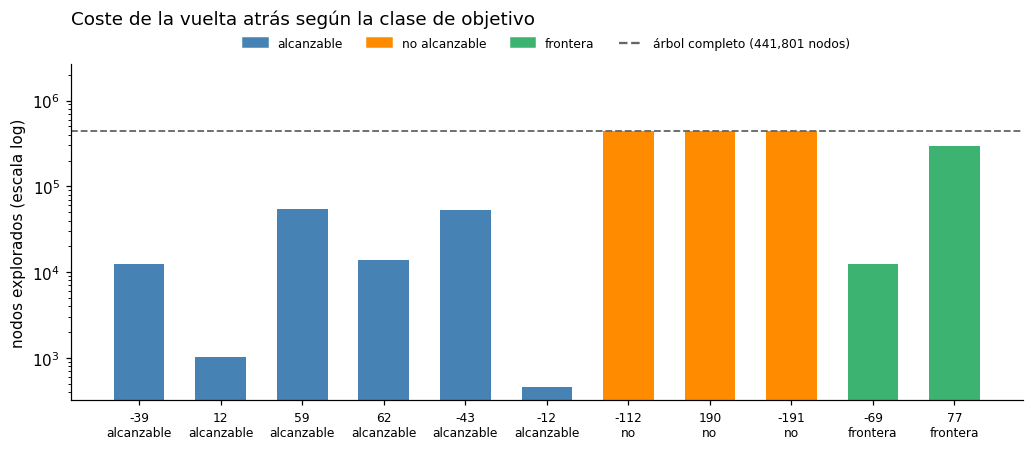

Nodos medios: 22,684 si el objetivo existe frente a 441,801 si no existe
El peor caso cuesta 19 veces más que el caso medio.


In [ ]:
# Figura 5 · Coste según la clase de objetivo
fig, ax = plt.subplots(figsize=(9.5, 4.2))
colores = {'alcanzable': AZUL, 'no alcanzable': NARANJA,
           'frontera (mínimo)': VERDE, 'frontera (máximo)': VERDE}
etiquetas = [f"{r.objetivo}\n{r.clase.split(' ')[0]}" for r in exp1.itertuples()]
ax.bar(range(len(exp1)), exp1['nodos'],
       color=[colores[c] for c in exp1['clase']], width=0.62)
ax.axhline(NODOS_ARBOL, color='0.4', ls='--', linewidth=1.2)
ax.set_yscale('log')
ax.set_xticks(range(len(exp1)))
ax.set_xticklabels(etiquetas, fontsize=8)
ax.set_ylabel('nodos explorados (escala log)')
ax.set_ylim(top=NODOS_ARBOL * 6)
ax.set_title('Coste de la vuelta atrás según la clase de objetivo', loc='left', pad=26)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=AZUL, label='alcanzable'),
                   Patch(color=NARANJA, label='no alcanzable'),
                   Patch(color=VERDE, label='frontera'),
                   Line2D([0], [0], color='0.4', ls='--',
                          label=f'árbol completo ({NODOS_ARBOL:,} nodos)')],
          fontsize=8, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.01),
          frameon=False)
plt.tight_layout(); plt.show()

alc = exp1[exp1['clase'] == 'alcanzable']['nodos'].mean()
inalc = exp1[exp1['clase'] == 'no alcanzable']['nodos'].mean()
print(f"Nodos medios: {alc:,.0f} si el objetivo existe frente a {inalc:,.0f} si no existe")
print(f"El peor caso cuesta {inalc/alc:.0f} veces más que el caso medio.")

In [ ]:
# Experimento 2 · El algoritmo sobre configuraciones alternativas del problema
filas = []
for cfg in CONFIGS_TEST:
    t0 = time.perf_counter()
    alcanzados, evaluadas = fuerza_bruta(cfg['cifras'], cfg['operadores'], cfg['k'])
    dt = time.perf_counter() - t0
    previsto = n_expresiones(cfg['n'], cfg['k'], cfg['m'])
    intervalo_n = max(alcanzados) - min(alcanzados) + 1 if alcanzados else 0
    filas.append({
        'n': cfg['n'], 'k': cfg['k'], 'm': cfg['m'],
        'operadores': ' '.join(cfg['operadores']),
        'N previsto': f"{previsto:,}", 'N evaluado': f"{evaluadas:,}",
        'coincide': 'sí' if previsto == evaluadas else 'NO',
        'mín': min(alcanzados) if alcanzados else None,
        'máx': max(alcanzados) if alcanzados else None,
        '|V|': len(alcanzados),
        'cobertura %': round(100*len(alcanzados)/intervalo_n, 1) if intervalo_n else 0,
        'ms': round(dt*1000, 1)})

exp2 = pd.DataFrame(filas)
print(exp2.to_string(index=False))
print()
print(f"La fórmula N(n,k,m) predice el nº de expresiones en "
      f"{sum(exp2['coincide']=='sí')} de {len(exp2)} configuraciones.")
print()
print("Observación relevante: la cobertura del intervalo cae por debajo del 100 %")
print("en las configuraciones con menos operadores o menos cifras. Es decir, la")
print("propiedad 'se obtienen todos los enteros intermedios' NO es general del")
print("problema: depende de que haya suficiente riqueza combinatoria, y en el caso")
print("del enunciado (n=9, k=5, m=4) se cumple por muy poco margen.")

 n  k  m operadores N previsto N evaluado coincide  mín  máx  |V|  cobertura %  ms
 5  3  3      / * -        360        360       sí  -52   52   57         54.3 0.5
 5  3  3      / + -        360        360       sí   -5   13   19        100.0 0.6
 7  3  2        * /        420        420       sí    1   72   17         23.6 0.6
 8  3  3      / - *      2,016      2,016       sí  -70   70  128         90.8 2.6
 7  4  3      - * /      5,040      5,040       sí  -61   61   96         78.0 8.1

La fórmula N(n,k,m) predice el nº de expresiones en 5 de 5 configuraciones.

Observación relevante: la cobertura del intervalo cae por debajo del 100 %
en las configuraciones con menos operadores o menos cifras. Es decir, la
propiedad 'se obtienen todos los enteros intermedios' NO es general del
problema: depende de que haya suficiente riqueza combinatoria, y en el caso
del enunciado (n=9, k=5, m=4) se cumple por muy poco margen.


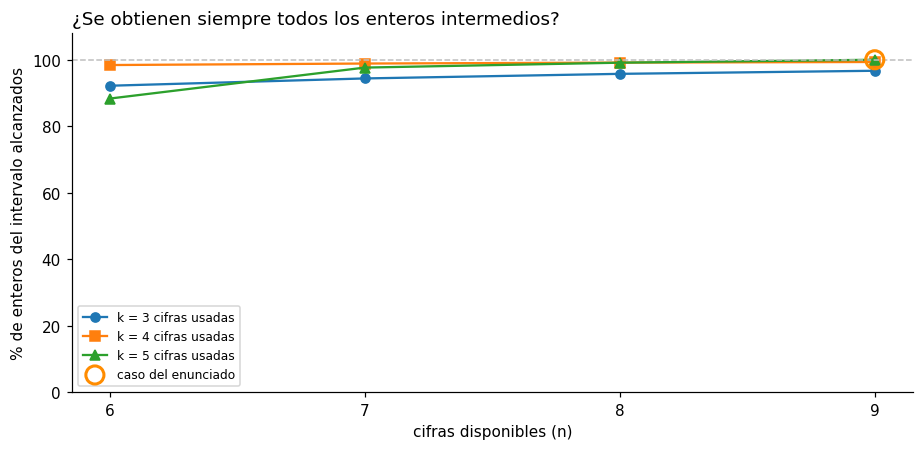

n     6     7     8      9
k                         
3  92.2  94.4  95.8   96.7
4  98.4  98.9  99.1   99.3
5  88.3  97.6  99.1  100.0

La cobertura del 100 % es una particularidad del caso n=9, k=5: con menos
cifras el intervalo queda con huecos. La respuesta afirmativa a la segunda
pregunta del enunciado no se generaliza.


In [ ]:
# Figura 6 · Cobertura del intervalo según la riqueza combinatoria
filas = []
for n in (6, 7, 8, 9):
    for k in (3, 4, 5):
        if k > n: continue
        alcanzados, _ = fuerza_bruta(CIFRAS[:n], OPERADORES, k)
        rango = max(alcanzados) - min(alcanzados) + 1
        filas.append({'n': n, 'k': k, 'cobertura': 100*len(alcanzados)/rango,
                      'N': n_expresiones(n, k, 4)})
cob = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for k, marcador in zip((3, 4, 5), ('o-', 's-', '^-')):
    sub = cob[cob['k'] == k]
    ax.plot(sub['n'], sub['cobertura'], marcador, label=f'k = {k} cifras usadas')
ax.axhline(100, color=GRIS, ls='--', linewidth=1)
ax.scatter([9], [100], s=140, facecolors='none', edgecolors=NARANJA, linewidths=2,
           label='caso del enunciado', zorder=5)
ax.set_xlabel('cifras disponibles (n)')
ax.set_ylabel('% de enteros del intervalo alcanzados')
ax.set_ylim(0, 108)
ax.set_xticks([6, 7, 8, 9])
ax.set_title('¿Se obtienen siempre todos los enteros intermedios?', loc='left')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(cob.pivot(index='k', columns='n', values='cobertura').round(1).to_string())
print()
print("La cobertura del 100 % es una particularidad del caso n=9, k=5: con menos")
print("cifras el intervalo queda con huecos. La respuesta afirmativa a la segunda")
print("pregunta del enunciado no se generaliza.")

---
## 10. Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

**Respuesta:**

**Material de la asignatura**

1. Reyero Díez, R. *Algoritmos de optimización*. Máster Universitario en Inteligencia Artificial,
   Universidad Internacional de Valencia. Capítulos consultados:
   - **1.4**, complejidad computacional y órdenes de complejidad, para el análisis de las
     preguntas 5 y 7.
   - **3.2**, vuelta atrás: esquema de diseño y resolución, base del algoritmo del objetivo B.
   - **5.3**, ramificación y poda, para el análisis de la conveniencia de la poda por cotas.
2. VIU. *VC4 — Problemas del Trabajo Práctico. 03MIAR Algoritmos de optimización*, pp. 8-9
   (enunciado del Problema 3) y pp. 15-20 (indicaciones sobre el entregable).

**Bibliografía**

3. Brassard, G. y Bratley, P. (1997). *Fundamentos de algoritmia*. Prentice Hall. Capítulo sobre
   exploración de grafos y vuelta atrás.
4. Cormen, T. H., Leiserson, C. E., Rivest, R. L. y Stein, C. (2009). *Introduction to Algorithms*
   (3.ª ed.). MIT Press. Fundamentos de complejidad computacional y notación asintótica.
5. Goldberg, D. (1991). "What Every Computer Scientist Should Know About Floating-Point Arithmetic".
   *ACM Computing Surveys*, 23(1), 5-48. Consultado para justificar la validación con aritmética
   exacta de la pregunta 3.
6. OpenAI. (2026). ChatGPT (Versión GPT-5.5 Pro de abril de 2026) [Modelo de lenguaje de gran tamaño]. https://chat.openai.com

**Documentación técnica**

7. Python Software Foundation (2024). *The Python Standard Library*:
   - `itertools.permutations`, generación de variaciones sin repetición.
   - `fractions.Fraction`, aritmética racional exacta.
   - `random.Random` y `random.sample`, generación reproducible de datos de prueba.
   - `set`, propiedades de los conjuntos: pertenencia e inserción en O(1) amortizado.
8. Python Software Foundation (2024). *Built-in Functions — `eval`*.
9. Hunter, J. D. (2007). "Matplotlib: A 2D Graphics Environment". *Computing in Science &
   Engineering*, 9(3), 90-95.
10. **Wikipedia.** (2025). *Permutación*.  
   - Definición matemática de \(P(n,k) = \dfrac{n!}{(n-k)!}\) para el cálculo de permutaciones.

---
## 11. Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

**Respuesta:**

### A. Mejoras sobre el algoritmo desarrollado

**Poda con cotas admisibles y demostradas.** El análisis de la pregunta 6 muestra que la poda por
cotas es un arma de doble filo: la cota empleada reduce los nodos en conjunto, pero no es admisible y
en algunos objetivos resulta contraproducente. La línea de trabajo natural es **derivar cotas
demostrablemente admisibles** a partir de la descomposición en tres bloques de la pregunta 3: conocido
el estado `(suma, termino)` y los operadores pendientes, el intervalo exacto de valores alcanzables se
puede acotar analíticamente en lugar de heurísticamente. Con una cota admisible y suficientemente
barata la poda sería siempre segura, aunque seguiría sin compensar en los objetivos que se resuelven
en pocos nodos.

**Programación dinámica sobre subexpresiones.** Muchos prefijos se recalculan entre ramas distintas
del árbol. Almacenar, para cada subconjunto de cifras y operadores consumidos, el conjunto de valores
alcanzables permitiría reutilizar ese cálculo. El estado sería $(\text{subconjunto de cifras},
\text{subconjunto de operadores}, \text{valor})$, con $2^n \cdot 2^m$ combinaciones de subconjuntos;
para $n=9$ y $m=4$ resultan 8 192 estados, perfectamente manejables. Esta es la única vía identificada
que podría **reducir el orden** y no solo el factor constante.

**Cotas para el máximo y el mínimo sin enumerar.** El argumento de los tres bloques permite deducir
$\max V$ y $\min V$ analíticamente, sin recorrer el espacio. Formalizarlo daría una respuesta a la
primera pregunta del enunciado en tiempo $O(1)$, reservando la enumeración únicamente para la segunda.

### B. Variaciones al alza del tamaño

Con $k$ creciente el espacio pasa de polinómico a factorial, según el análisis de la pregunta 5. Las
líneas aplicables son:

- **Evaluación vectorizada.** Generar las variaciones como matrices de `numpy` y evaluar todas las
  expresiones en paralelo mediante operaciones sobre arrays, eliminando el bucle de Python.
- **Paralelización por primera cifra.** Las 9 ramas de primer nivel son independientes, de modo que se
  reparten sin sincronización entre procesos.
- **Aritmética exacta selectiva.** Al crecer $k$ aumenta la profundidad de las divisiones encadenadas
  y el margen de seguridad de la coma flotante medido en la pregunta 3 se reduce. Convendría emplear
  `Fraction` para los casos próximos a un entero y `float` para el resto.

### C. Variaciones del problema

| Variación | Efecto sobre el modelo |
|---|---|
| **Permitir paréntesis** | Desaparece la descomposición en tres bloques, base de todo el análisis del máximo y el mínimo. El número de agrupaciones sigue los números de Catalan, multiplicando el espacio por $C_{k-1}$ |
| **Permitir repetir cifras u operadores** | Se recupera el conteo $n^k \cdot m^{k-1}$ de la pregunta 1; el espacio se multiplica por 42 en el caso del enunciado |
| **Añadir operadores** (potencia, módulo) | Rompe la propiedad de que todos los bloques son positivos, y con ella el análisis de extremos |
| **Concatenar cifras** (formar el número 23 con un 2 y un 3) | Amplía enormemente el recorrido y exige reescribir el evaluador |
| **Buscar la expresión más corta** para un objetivo | Convierte el problema en uno de optimización propiamente dicho, con función objetivo sobre la longitud |
| **Contar cuántas expresiones dan cada valor** | Es un problema de conteo, no de búsqueda; la figura 2 lo resuelve para el caso del enunciado |

### D. Preguntas abiertas que este trabajo deja planteadas

El experimento 2 de la pregunta 9 revela un resultado que no estaba previsto: **la cobertura completa
del intervalo no es una propiedad general del problema**, sino una particularidad del caso $n=9$,
$k=5$, $m=4$. Con menos cifras o menos operadores aparecen huecos. Determinar la **condición mínima
sobre $(n,k,m)$ que garantiza la cobertura completa** es una pregunta bien definida que este trabajo
no responde y que constituye la continuación más natural del estudio.

---

Gracias por su atención. Esperamos que este trabajo refleje nuestro esfuerzo y aprendizaje para el desarrollo de la actividad.

**Nur Derly Carpeta Sánchez**

**William René Moreno Romero**

**Materia:** Algoritmos de Optimización

**Máster Universitario en Inteligencia Artificial**